# **Práctica de Laboratorio 1: Programación Dinámica**

### **DS5345 - Aprendizaje por Refuerzo | UTEC 2026-II**

---

**Profesor:** Percy W. Lovon Ramos  
**Duración:** 105 minutos  
**Modalidad:** Individual  
**Entrega:** Subir este archivo `.ipynb` ejecutado con todas las salidas y respuestas a Canvas.
**Estudiante:** Jeffrey Antonio Monja Castro

---


## **1. Configuración y Definición del Entorno GridWorld**

El entorno corresponde al clásico **Grid World 5x5** propuesto por _Sutton & Barto_ (Ejemplo 3.5 / 3.8).

### **Especificaciones del MDP:**

- **Espacio de Estados $\mathcal{S}$:** 25 casillas numeradas del $0$ al $24$ ($s = y \cdot 5 + x$, con $y, x \in \{0, 1, 2, 3, 4\}$).
- **Espacio de Acciones $\mathcal{A}$:** 4 acciones deterministas:
  - `0`: **Norte** $(\Delta y = -1, \Delta x = 0)$
  - `1`: **Este** $(\Delta y = 0, \Delta x = +1)$
  - `2`: **Sur** $(\Delta y = +1, \Delta x = 0)$
  - `3`: **Oeste** $(\Delta y = 0, \Delta x = -1)$
- **Dinámica y Recompensas:**
  - **Estado A** $(y=0, x=1 \implies s=1)$: Cualquier acción da **$r = +10$** y teletransporta a $A' = (4, 1 \implies s'=21)$.
  - **Estado B** $(y=0, x=3 \implies s=3)$: Cualquier acción da **$r = +5$** y teletransporta a $B' = (2, 3 \implies s'=13)$.
  - **Movimientos válidos:** Si el siguiente estado permanece dentro de la cuadrícula, da **$r = 0$**.
  - **Fuera del tablero (Paredes):** Si la acción intenta salir del tablero, da **$r = -1$** y el agente **mantiene su posición** ($s' = s$).

> **Nota de Conteo:** Cada llamada a la función `gridworld(s, a)` cuenta como **1 observación / evaluación del modelo**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes de acciones
NORTH, EAST, SOUTH, WEST = 0, 1, 2, 3
ACTION_NAMES = ["Norte", "Este", "Sur", "Oeste"]
NUM_STATES = 25
NUM_ACTIONS = 4


def gridworld(s, a):
    """
    Modelo de transición y recompensa del Gridworld 5x5 (Sutton & Barto).

    Parámetros:
        s (int): Estado actual (0 <= s <= 24)
        a (int): Acción (0: Norte, 1: Este, 2: Sur, 3: Oeste)

    Retorna:
        r (float): Recompensa inmediata
        sp (int): Estado sucesor s'
    """
    y = s // 5
    x = s % 5

    # Estados especiales A y B
    if y == 0:
        if x == 1:  # Estado A
            return 10.0, 4 * 5 + 1  # A' (4, 1)
        elif x == 3:  # Estado B
            return 5.0, 2 * 5 + 3  # B' (2, 3)

    # Movimiento determinista
    if a == NORTH:
        y -= 1
    elif a == EAST:
        x += 1
    elif a == SOUTH:
        y += 1
    elif a == WEST:
        x -= 1

    r = 0.0
    # Verificación de límites de la cuadrícula
    if x < 0:
        r = -1.0
        x = 0
    elif x > 4:
        r = -1.0
        x = 4
    elif y < 0:
        r = -1.0
        y = 0
    elif y > 4:
        r = -1.0
        y = 4

    sp = y * 5 + x
    return r, sp

In [2]:
def plotv(v, policy=None, title="Gridworld $V(s)$ y $\\pi(s)$"):
    """
    Grafica la función de valor V y la política en la cuadrícula 5x5.
    Basado en la función plotv de MATLAB.
    """
    v = np.array(v, dtype=float).flatten()

    # Si no se proporciona política, se deriva de forma voraz respecto a V
    if policy is None:
        policy = np.zeros(NUM_STATES, dtype=int)
        for s in range(NUM_STATES):
            q_values = np.zeros(NUM_ACTIONS)
            for a in range(NUM_ACTIONS):
                r, sp = gridworld(s, a)
                q_values[a] = r + 0.9 * v[sp]
            policy[s] = np.argmax(q_values)
    else:
        policy = np.array(policy, dtype=int).flatten()

    fig, ax = plt.subplots(figsize=(6.5, 6.5))

    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(4.5, -0.5)  # Eje Y invertido (fila 0 arriba, fila 4 abajo)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels([f"Col {x}" for x in range(5)], fontsize=10)
    ax.set_yticklabels([f"Fila {y}" for y in range(5)], fontsize=10)
    ax.grid(True, color="gray", linestyle="--", linewidth=0.7, alpha=0.6)

    # Sombrado para casillas especiales A y B
    ax.add_patch(
        plt.Rectangle(
            (0.5, -0.5), 1, 1, fill=True, color="#d4edda", alpha=0.7, zorder=1
        )
    )
    ax.text(
        1,
        -0.32,
        "A (+10)",
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#155724",
        zorder=4,
    )

    ax.add_patch(
        plt.Rectangle(
            (2.5, -0.5), 1, 1, fill=True, color="#cce5ff", alpha=0.7, zorder=1
        )
    )
    ax.text(
        3,
        -0.32,
        "B (+5)",
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#004085",
        zorder=4,
    )

    action_dirs = {
        NORTH: (0, -0.33),
        EAST: (0.33, 0),
        SOUTH: (0, 0.33),
        WEST: (-0.33, 0),
    }

    for s in range(NUM_STATES):
        y = s // 5
        x = s % 5
        a = policy[s]
        dx, dy = action_dirs[a]

        # Flecha de acción
        ax.annotate(
            "",
            xy=(x + dx, y + dy),
            xytext=(x, y),
            arrowprops=dict(
                arrowstyle="->", lw=2.2, color="#c0392b", shrinkA=0, shrinkB=0
            ),
            zorder=3,
        )

        # Valor numérico V(s)
        val_str = f"{v[s]:.1f}"
        ax.text(
            x,
            y,
            val_str,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="#333333",
                alpha=0.9,
                lw=1.2,
            ),
            zorder=4,
        )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

---


## **2. Sección 3: Evaluación de Política (Policy Evaluation)**

Dada una política determinista $\pi(s)$, la ecuación de actualización de Bellman para el caso determinista es:

$$V_{k+1}(s) \leftarrow \mathcal{R}(s, \pi(s)) + \gamma V_k(\mathcal{T}(s, \pi(s)))$$

### **Instrucciones:**

1. Implementa la función `policy_evaluation(pi, gamma, theta)` que itera hasta que $\Delta = \max_{s} |V_{k+1}(s) - V_k(s)| < \theta$.
2. Evalúa una política determinista inicial que elija siempre la acción **Norte** (`pi[s] = NORTH` para todo $s$).
3. Usa $\gamma = 0.9$ y $\theta = 10^{-5}$.
4. Cuenta el número total de llamadas a `gridworld(s, a)` (observaciones).
5. Grafica la función de valor resultante con `plotv(V, pi)`.


In [3]:
def policy_evaluation(pi, gamma=0.9, theta=1e-5):
    """
    Evalúa una política determinista pi iterativamente.

    Retorna:
        V (np.ndarray): Vector de valor V^pi de tamaño 25
        num_observations (int): Número total de consultas a gridworld
    """
    V = np.zeros(NUM_STATES)
    num_observations = 0

    # TODO: Implementa el algoritmo de Policy Evaluation
    # 1. Bucle while True:
    # 2.   delta = 0
    # 3.   Para cada s en range(NUM_STATES):
    # 4.       a = pi[s]
    # 5.       r, sp = gridworld(s, a)
    # 6.       Incrementar num_observations en 1
    # 7.       v_nuevo = r + gamma * V[sp]
    # 8.       delta = max(delta, |v_nuevo - V[s]|)
    # 9.       Actualizar V[s]
    # 10.  Si delta < theta: terminar bucle

    while True:
        delta = 0
        for s in range(NUM_STATES):
            a = pi[s]
            r, sp = gridworld(s, a)
            num_observations += 1
            v_nuevo = r + gamma * V[sp]
            delta = max(delta, abs(v_nuevo - V[s]))
            V[s] = v_nuevo

        if delta < theta:
            break

    return V, num_observations

Total de observaciones (Policy Evaluation - Norte): 2775
Función de Valor V (matriz 5x5):
[[-10.   24.4 -10.   18.5 -10. ]
 [ -9.   22.   -9.   16.6  -9. ]
 [ -8.1  19.8  -8.1  14.9  -8.1]
 [ -7.3  17.8  -7.3  13.5  -7.3]
 [ -6.6  16.   -6.6  12.1  -6.6]]


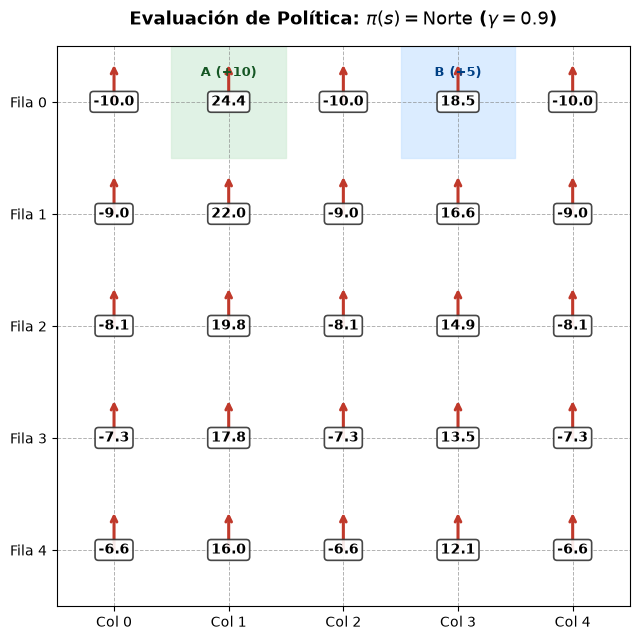

In [11]:
# --- Evaluación de la Política Norte ---
pi_north = np.full(NUM_STATES, NORTH, dtype=int)
V_north, obs_north = policy_evaluation(pi_north, gamma=0.9, theta=1e-5)

print(f"Total de observaciones (Policy Evaluation - Norte): {obs_north}")
print("Función de Valor V (matriz 5x5):")
print(np.round(V_north.reshape(5, 5), 1))

# Graficar
plotv(
    V_north,
    pi_north,
    title="Evaluación de Política: $\\pi(s) = \\text{Norte}$ ($\\gamma=0.9$)",
)

---


## **3. Sección 4: Mejora de Política e Iteración de Política (Policy Iteration)**

El algoritmo de **Policy Iteration** alterna dos etapas:

1. **Evaluación de Política:** Calcula $V^\pi(s)$ para la política actual $\pi$.
2. **Mejora de Política (Greedy):** Actualiza la política eligiendo la mejor acción:
   $$\pi'(s) \leftarrow \arg\max_{a \in \mathcal{A}} \Big( \mathcal{R}(s, a) + \gamma V(\mathcal{T}(s, a)) \Big)$$
3. Si $\pi'(s) = \pi(s)$ para todo $s$, la política es óptima (estable) y el algoritmo termina.

### **Instrucciones:**

1. Implementa `policy_improvement(V, gamma)` y `policy_iteration(gamma, theta)`.
2. Ejecuta el algoritmo iniciando desde `pi_0` (todas las acciones hacia el Norte).
3. Reporta el número total de observaciones y de ciclos de mejora de política.
4. Grafica la política óptima $\pi^*$ y la función de valor óptima $V^*$ resultante.


In [5]:
def policy_improvement(V, gamma=0.9):
    """
    Mejora la política de forma voraz con respecto a V.

    Retorna:
        new_pi (np.ndarray): Nueva política voraz (tamaño 25)
        obs (int): Número de consultas a gridworld en este paso
    """
    new_pi = np.zeros(NUM_STATES, dtype=int)
    obs = 0

    # TODO: Implementa la mejora de política
    # Para cada estado s:
    #   Calcular q(s, a) = R(s,a) + gamma * V(T(s,a)) para cada una de las 4 acciones a
    #   new_pi[s] = argmax_a q(s, a)
    for s in range(NUM_STATES):
        q_values = np.zeros(NUM_ACTIONS)
        for a in range(NUM_ACTIONS):
            r, sp = gridworld(s, a)
            obs += 1
            q_values[a] = r + gamma * V[sp]
        new_pi[s] = np.argmax(q_values)

    return new_pi, obs


def policy_iteration(gamma=0.9, theta=1e-5):
    """
    Ejecuta el algoritmo completo de Policy Iteration.

    Retorna:
        V (np.ndarray): Función de valor óptima V*
        pi (np.ndarray): Política óptima pi*
        total_obs (int): Total de observaciones (evaluación + mejora)
        cycles (int): Número de ciclos completos de política
    """
    pi = np.zeros(NUM_STATES, dtype=int)  # Inicialmente Norte
    V = np.zeros(NUM_STATES)
    total_obs = 0
    cycles = 0

    # TODO: Implementa el bucle de Policy Iteration
    # Bucle:
    #   1. Evaluar pi -> obtener V y sumar observaciones
    #   2. Mejorar pi -> obtener new_pi y sumar observaciones
    #   3. Incrementar cycles
    #   4. Si new_pi es igual a pi: terminar; si no: pi = new_pi

    while True:
        V, obs_eval = policy_evaluation(pi, gamma, theta)
        total_obs += obs_eval

        new_pi, obs_improve = policy_improvement(V, gamma)
        total_obs += obs_improve

        cycles += 1

        if np.array_equal(new_pi, pi):
            break

        pi = new_pi

    return V, pi, total_obs, cycles

Policy Iteration finalizado en 5 ciclos de mejora.
Total de observaciones (consultas a gridworld): 6525

Función de Valor Óptima V*:
[[22.  24.4 22.  19.4 17.5]
 [19.8 22.  19.8 17.8 16. ]
 [17.8 19.8 17.8 16.  14.4]
 [16.  17.8 16.  14.4 13. ]
 [14.4 16.  14.4 13.  11.7]]


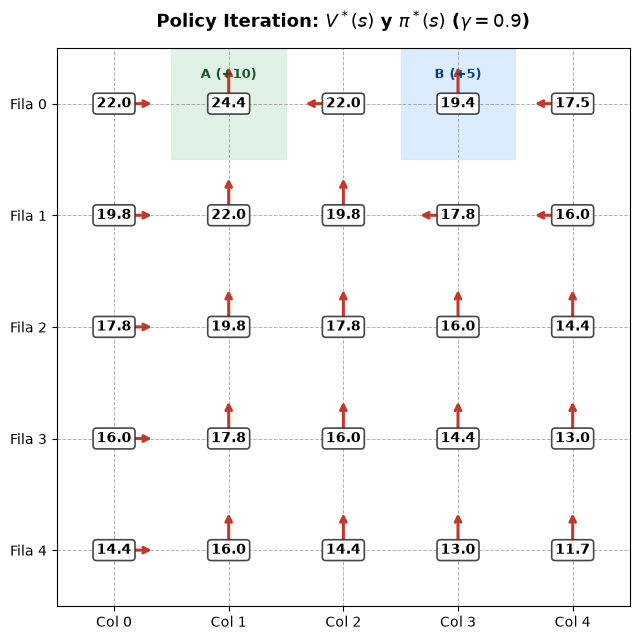

In [6]:
# --- Ejecutar Policy Iteration (gamma = 0.9) ---
V_opt, pi_opt, obs_pi, cycles_pi = policy_iteration(gamma=0.9, theta=1e-5)

print(f"Policy Iteration finalizado en {cycles_pi} ciclos de mejora.")
print(f"Total de observaciones (consultas a gridworld): {obs_pi}")
print("\nFunción de Valor Óptima V*:")
print(np.round(V_opt.reshape(5, 5), 1))

# Graficar
plotv(V_opt, pi_opt, title="Policy Iteration: $V^*(s)$ y $\\pi^*(s)$ ($\\gamma=0.9$)")

**¿Cuántas observaciones y cuántos cilocs completos de mejora de política tomó converger?**

> _Obs = 6525, Ciclos = 5_


---


## **4. Sección 5: Sensibilidad al Factor de Descuento $\gamma$**

El factor $\gamma$ controla la visión a futuro del agente:

- $\gamma \to 1$: El agente prioriza retornos a largo plazo.
- $\gamma \to 0$: El agente es miope y busca recompensa inmediata.

### **Instrucciones:**

1. Ejecuta Policy Iteration con $\gamma = 0.8$.
2. Grafica y compara los resultados numéricos y visuales.
3. Responde a las preguntas de análisis en la celda de texto posterior.


Policy Iteration (gamma=0.8) finalizado en 3 ciclos.
Total de observaciones: 2675

Función de Valor Óptima V* (gamma=0.8):
[[11.9 14.9 11.9 10.2  8.2]
 [ 9.5 11.9  9.5  8.2  6.6]
 [ 7.6  9.5  7.6  6.6  5.2]
 [ 6.1  7.6  6.1  5.2  4.2]
 [ 4.9  6.1  4.9  4.2  3.4]]


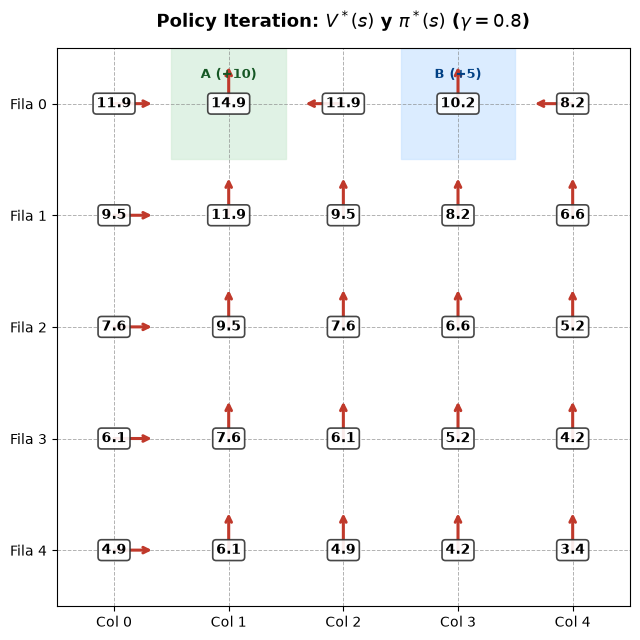

In [7]:
# --- Ejecutar Policy Iteration con gamma = 0.8 ---
V_opt_08, pi_opt_08, obs_pi_08, cycles_pi_08 = policy_iteration(gamma=0.8, theta=1e-5)

print(f"Policy Iteration (gamma=0.8) finalizado en {cycles_pi_08} ciclos.")
print(f"Total de observaciones: {obs_pi_08}")
print("\nFunción de Valor Óptima V* (gamma=0.8):")
print(np.round(V_opt_08.reshape(5, 5), 1))

plotv(
    V_opt_08,
    pi_opt_08,
    title="Policy Iteration: $V^*(s)$ y $\\pi^*(s)$ ($\\gamma=0.8$)",
)

### **Preguntas de Análisis - Sensibilidad de $\gamma$:**

1. **¿Qué cambios cualitativos observas en la política $\pi^*$ y en la magnitud de los valores de $V^*$ al reducir $\gamma$ de $0.9$ a $0.8$?**

   > _Al reducir $\gamma$ de $0.9$ a $0.8$, se observa que la política $\pi^*$ tiende a priorizar acciones que proporcionan recompensas inmediatas, en lugar de aquellas que podrían conducir a mayores recompensas a largo plazo. Esto se refleja en la función de valor $V^*$, donde los valores asociados a estados cercanos a las recompensas inmediatas (como los estados A y B) son relativamente más altos, mientras que los valores de estados más alejados disminuyen, indicando una menor valoración de las recompensas futuras._

2. **¿Cómo afecta $\gamma = 0.8$ al número total de observaciones e iteraciones necesarias para converger? Explica por qué.**
   > _Con $\gamma = 0.8$, el número total de observaciones = 2675 y las iteraciones = 3, en comparación con $\gamma = 0.9$. Esto se debe a que un menor factor de descuento hace que el agente sea más miope, enfocándose en recompensas inmediatas y reduciendo la complejidad del cálculo de valores futuros. Como resultado, la política converge más rápidamente, ya que las diferencias entre los valores de los estados se estabilizan más rápido al priorizar recompensas cercanas._


---


## **5. Sección 6: Iteración de Valor (Value Iteration)**

En lugar de esperar la convergencia completa de la evaluación de política, **Value Iteration** realiza una sola actualización de optimalidad de Bellman por cada estado en cada barrido:

$$V_{k+1}(s) \leftarrow \max_{a \in \mathcal{A}} \Big( \mathcal{R}(s, a) + \gamma V_k(\mathcal{T}(s, a)) \Big)$$

Al converger (cuando $\Delta = \max_{s} |V_{k+1}(s) - V_k(s)| < \theta$), la política óptima $\pi^*$ se extrae tomando el $\arg\max_a$.

### **Instrucciones:**

1. Implementa la función `value_iteration(gamma=0.9, theta=1e-5)`.
2. Extrae la política óptima voraz resultante.
3. Compara $V^*$ y $\pi^*$ con los obtenidos en Policy Iteration.
4. Compara el total de observaciones requeridas entre ambos métodos.


In [27]:
def value_iteration(gamma=0.9, theta=1e-5):
    """
    Ejecuta el algoritmo de Value Iteration.

    Retorna:
        V (np.ndarray): Función de valor óptima V*
        pi (np.ndarray): Política óptima extraída pi*
        num_observations (int): Total de consultas a gridworld
        sweeps (int): Número de barridos completos sobre la cuadrícula
    """
    V = np.zeros(NUM_STATES)
    pi = np.zeros(NUM_STATES, dtype=int)
    num_observations = 0
    sweeps = 0

    # TODO: Implementa Value Iteration
    # Bucle:
    #   delta = 0
    #   Para cada estado s:
    #       Calcular q(s, a) = R(s,a) + gamma * V[T(s,a)] para las 4 acciones a
    #       v_nuevo = max_a q(s, a)
    #       delta = max(delta, |v_nuevo - V[s]|)
    #       Actualizar V[s]
    #   Si delta < theta: terminar
    # Extraer la política óptima voraz pi[s] = argmax_a q(s, a)

    while True:
        delta = 0
        for s in range(NUM_STATES):
            q_values = np.zeros(NUM_ACTIONS)
            for a in range(NUM_ACTIONS):
                r, sp = gridworld(s, a)
                num_observations += 1
                q_values[a] = r + gamma * V[sp]
            v_nuevo = np.max(q_values)
            delta = max(delta, abs(v_nuevo - V[s]))
            V[s] = v_nuevo

        sweeps += 1

        if delta < theta:
            break

    for s in range(NUM_STATES):
        q_values = np.zeros(NUM_ACTIONS)
        for a in range(NUM_ACTIONS):
            r, sp = gridworld(s, a)
            num_observations += 1
            q_values[a] = r + gamma * V[sp]
        pi[s] = np.argmax(q_values)

    return V, pi, num_observations, sweeps

Value Iteration convergió en 29 barridos.
Total de observaciones: 3000

Función de Valor V* (Value Iteration):
[[22.  24.4 22.  19.4 17.5]
 [19.8 22.  19.8 17.8 16. ]
 [17.8 19.8 17.8 16.  14.4]
 [16.  17.8 16.  14.4 13. ]
 [14.4 16.  14.4 13.  11.7]]


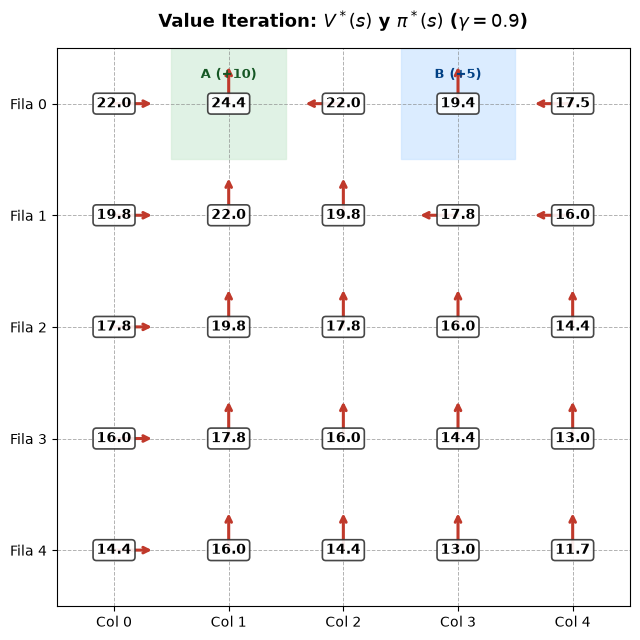

In [28]:
# --- Ejecutar Value Iteration (gamma = 0.9) ---
V_vi, pi_vi, obs_vi, sweeps_vi = value_iteration(gamma=0.9, theta=1e-5)

print(f"Value Iteration convergió en {sweeps_vi} barridos.")
print(f"Total de observaciones: {obs_vi}")
print("\nFunción de Valor V* (Value Iteration):")
print(np.round(V_vi.reshape(5, 5), 1))

# Graficar
plotv(V_vi, pi_vi, title="Value Iteration: $V^*(s)$ y $\\pi^*(s)$ ($\\gamma=0.9$)")

In [24]:
igual = np.array_equal(pi_opt, pi_vi)
diff = np.max(np.abs(V_opt - V_vi))

print(f"Son iguales: {igual}")
print(f"Diferencia máxima entre valores: {diff:.8f}")

print("\nPi (Policy Iteration):")
print(pi_opt.reshape(5, 5))

print("\nPi (Value Iteration):")
print(pi_vi.reshape(5, 5))

Son iguales: True
Diferencia máxima entre valores: 0.00000000

Pi (Policy Iteration):
[[1 0 3 0 3]
 [1 0 0 3 3]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]]

Pi (Value Iteration):
[[1 0 3 0 3]
 [1 0 0 3 3]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]]


### **Comparación: Policy Iteration vs. Value Iteration**

| Métrica                                                      | Policy Iteration | Value Iteration |
| :----------------------------------------------------------- | :--------------- | :-------------- |
| **Total de Observaciones (Consultas a `gridworld`)**         | 6525             | 3000            |
| **¿Coincide la política óptima $\pi^*$?**                    | Sí               | Sí              |
| **Diferencia máxima en $V^*$ ($\max \|V_{PI} - V_{VI}\|$ )** | 0                | 0.00000000      |

<br>

> **Comentario:** Explica brevemente por qué difiere el número de observaciones entre ambos métodos.

> Ambos métodos obtienen el mismo $V^*$ y una política óptima equivalente. Value Iteration usa menos observaciones porque actualiza directamente con la ecuación de optimalidad de Bellman; Policy Iteration alterna evaluaciones completas y mejoras.


---


## **6. Sección 7: Iteración de Valor Asíncrona (Bonus)**

En lugar de barrer sistemáticamente todos los 25 estados en cada paso, la versión asíncrona aleatoria selecciona en cada iteración un único estado $s$ al azar con probabilidad uniforme:

$$s \sim \mathcal{U}\{0, 24\}$$
$$V(s) \leftarrow \max_{a \in \mathcal{A}} \Big( \mathcal{R}(s, a) + \gamma V(\mathcal{T}(s, a)) \Big)$$

### **Instrucciones:**

1. Implementa `asynchronous_value_iteration(num_iterations=250, gamma=0.9)`.
2. Realiza exactamente $N = 250$ actualizaciones de estados individuales.
3. Verifica que se efectúan exactamente $250 \times 4 = 1000$ observaciones del entorno.
4. Grafica la política y los valores resultantes y responde a las preguntas.


In [34]:
def asynchronous_value_iteration(num_iterations=250, gamma=0.9, seed=42):
    """
    Ejecuta Value Iteration Asíncrono seleccionando estados aleatorios.

    Retorna:
        V (np.ndarray): Función de valor tras num_iterations actualizaciones
        pi (np.ndarray): Política voraz extraída
        num_observations (int): Total de consultas a gridworld
    """
    np.random.seed(seed)
    V = np.zeros(NUM_STATES)
    num_observations = 0

    # TODO: Implementa Value Iteration Asíncrono
    # Para step in range(num_iterations):
    #   1. Elegir s aleatorio: s = np.random.randint(0, NUM_STATES)
    #   2. Calcular q(s, a) para las 4 acciones
    #   3. Actualizar V[s] = max_a q(s, a)
    #   4. Sumar 4 observaciones
    # Extraer la política voraz final

    for _ in range(num_iterations):
        s = np.random.randint(0, NUM_STATES)
        q_values = np.zeros(NUM_ACTIONS)
        for a in range(NUM_ACTIONS):
            r, sp = gridworld(s, a)
            num_observations += 1
            q_values[a] = r + gamma * V[sp]
        V[s] = np.max(q_values)

    update_observations = num_observations
    assert update_observations == num_iterations * NUM_ACTIONS

    pi = np.zeros(NUM_STATES, dtype=int)
    for s in range(NUM_STATES):
        q_values = np.zeros(NUM_ACTIONS)
        for a in range(NUM_ACTIONS):
            r, sp = gridworld(s, a)
            num_observations += 1
            q_values[a] = r + gamma * V[sp]
        pi[s] = np.argmax(q_values)

    return V, pi, num_observations

Observaciones de las 250 actualizaciones: 1000
Observaciones totales, incluida la extracción de pi: 1100

Función de Valor V (Asíncrona):
[[19.3 21.5 19.3 14.4 13. ]
 [17.4 17.5 15.7 14.1 12.7]
 [14.1 15.7 11.6 10.4 11.5]
 [12.7 14.1  6.6  9.4 10.3]
 [11.5 12.7 11.5 10.3  7.6]]

Pi (Asíncrona):
[[1 0 3 0 3]
 [0 0 0 3 3]
 [0 0 0 0 0]
 [0 0 3 0 0]
 [0 0 3 3 0]]


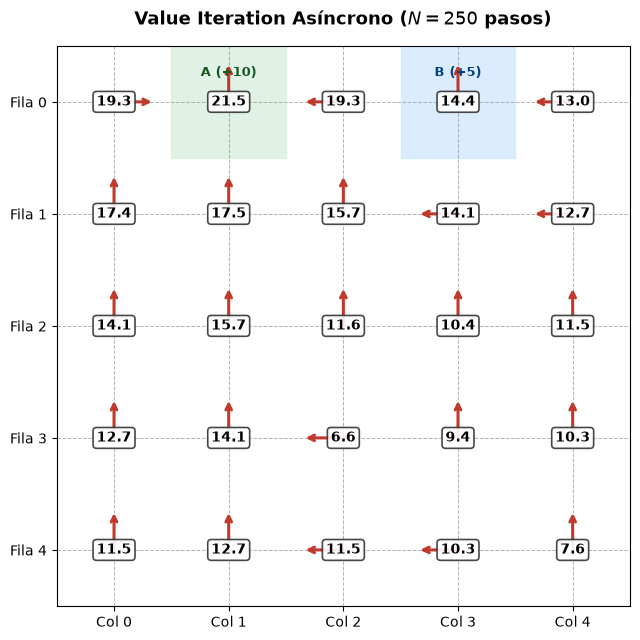

In [35]:
# --- 250 actualizaciones = 1000 consultas; extracción de pi = 100 consultas ---
V_async, pi_async, obs_async = asynchronous_value_iteration(
    num_iterations=250, gamma=0.9
)

print("Observaciones de las 250 actualizaciones: 1000")
print(f"Observaciones totales, incluida la extracción de pi: {obs_async}")
print("\nFunción de Valor V (Asíncrona):")
print(np.round(V_async.reshape(5, 5), 1))
print("\nPi (Asíncrona):")
print(pi_async.reshape(5, 5))

# Graficar
plotv(V_async, pi_async, title="Value Iteration Asíncrono ($N=250$ pasos)")

### **Preguntas de Análisis - Value Iteration Asíncrono:**

1. **¿Qué diferencias observas entre el mapa de valor obtenido con 250 iteraciones asíncronas frente al $V^*$ óptimo exacto de la Sección 4/6?**

   > _Con 250 actualizaciones, el mapa asíncrono conserva la estructura general de $V^*$, es decir, los valores más altos siguen cerca de A, pero subestima varios estados porque no realiza barridos completos. El caso más claro es $s=17$, que obtiene 6.6 frente a 16.0 en $V^*$, una diferencia de 9.4. Por tanto, las recompensas de A y B todavía no se han propagado uniformemente por toda la cuadrícula._

2. **¿Por qué algunos estados tienen valores visiblemente inferiores a su valor óptimo? ¿Qué condición teórica garantiza que Value Iteration Asíncrono converja al óptimo global?**
   > _Porque cada actualización usa los valores disponibles en ese momento; si los sucesores aún están subestimados, ese error también se propaga, resultando en una aproximación menos precisa del valor óptimo. La convergencia está garantizada porque, con $\gamma=0.9<1$, el operador de Bellman es una contracción, siempre que cada estado se actualice infinitas veces. La selección uniforme aleatoria cumple esta condición con probabilidad 1 si el proceso continúa indefinidamente._
